# A Data-Driven Insights on Predicting Cause of Crash Outcomes in  Chicago 
___
**Author**: Cynthia Jemutai  
**Date**:  03-05-2026  
**Project**:  Phase 3 Project  
**Data Sources**: [Traffic Crashes Vehicles.cvs]
___

## 1. Business Understanding



**Business Context**
* Traffic crashes in Chicago are caused by a wide range of contributing factors such as driver behavior, road conditions, and environmental circumstances. Understanding these causes is critical for reducing accidents and improving road safety.


**Business Objectives**
* This project aims to build a machine learning model that predicts the **primary contributory cause of a crash** using vehicle-level and environmental data. This yielded the following business specific objectives:
    *   Identify key causes of crashes
    *   Support targeted safety interventions
    *   Improve policy and infrastructure decisions

* It also predict crash interaction patterns (first_contact_point) using vehicle type, occupancy, and driving behavior (maneuver)


## 2.Data Understanding

In [1]:
#importing libraries
import statsmodels.api as sm
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures, StandardScaler
from scipy import stats


In [2]:
#loading data
df = pd.read_csv('Traffic Crashes Vehicles.csv')
df.head()

C:\Users\Cynthia\AppData\Local\Temp\ipykernel_5720\1789066300.py:2: DtypeWarning: Columns (0,20,39,40,41,47,48,49,52,54,57,58,60,70) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Traffic Crashes Vehicles.csv')


,CRASH_UNIT_ID,CRASH_RECORD_ID,CRASH_DATE,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,...,TRAILER1_LENGTH,TRAILER2_LENGTH,TOTAL_VEHICLE_LENGTH,AXLE_CNT,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS
0,2293647,2f29d3149c6f3d46e841f26e6bc59b73fc7cec8f0f6d3c...,04/29/2026 12:01:00 AM,1.0,DRIVER,NaN,2187489.0,NaN,HONDA,CR-V,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2293648,2f29d3149c6f3d46e841f26e6bc59b73fc7cec8f0f6d3c...,04/29/2026 12:01:00 AM,2.0,DRIVER,NaN,2187492.0,NaN,FORD,FUSION,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2293639,f9ce42096418494712b7b08cc6334e32daebadd7b0a0bb...,04/28/2026 11:30:00 PM,1.0,DRIVER,NaN,2187483.0,NaN,DODGE,JOURNEY,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2293632,2528ade688727b82a701d6cb27c65c0c9b75d63828a549...,04/28/2026 11:00:00 PM,1.0,DRIVER,NaN,2187473.0,NaN,TOYOTA,TUNDRA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2293633,2528ade688727b82a701d6cb27c65c0c9b75d63828a549...,04/28/2026 11:00:00 PM,2.0,DRIVER,1.0,2187475.0,NaN,SUBARU,FORESTER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
#checking for missing values
df.isnull().sum()

CRASH_UNIT_ID                   0
CRASH_RECORD_ID                 5
CRASH_DATE                      5
UNIT_NO                         5
UNIT_TYPE                     363
                            ...  
CARGO_BODY_TYPE            528716
LOAD_TYPE                  528903
HAZMAT_OUT_OF_SERVICE_I    528983
MCS_OUT_OF_SERVICE_I       529004
HAZMAT_CLASS               532111
Length: 71, dtype: int64

In [4]:
#data overview
df.shape
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 532358 entries, 0 to 532357
Data columns (total 71 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   CRASH_UNIT_ID             532358 non-null  object 
 1   CRASH_RECORD_ID           532353 non-null  object 
 2   CRASH_DATE                532353 non-null  object 
 3   UNIT_NO                   532353 non-null  float64
 4   UNIT_TYPE                 531995 non-null  object 
 5   NUM_PASSENGERS            78090 non-null   float64
 6   VEHICLE_ID                518192 non-null  float64
 7   CMRC_VEH_I                9632 non-null    object 
 8   MAKE                      518192 non-null  object 
 9   MODEL                     518192 non-null  object 
 10  LIC_PLATE_STATE           471581 non-null  object 
 11  VEHICLE_YEAR              445483 non-null  float64
 12  VEHICLE_DEFECT            518192 non-null  object 
 13  VEHICLE_TYPE              518192 non-null  o

,CRASH_UNIT_ID,CRASH_RECORD_ID,CRASH_DATE,UNIT_NO,UNIT_TYPE,NUM_PASSENGERS,VEHICLE_ID,CMRC_VEH_I,MAKE,MODEL,...,TRAILER1_LENGTH,TRAILER2_LENGTH,TOTAL_VEHICLE_LENGTH,AXLE_CNT,VEHICLE_CONFIG,CARGO_BODY_TYPE,LOAD_TYPE,HAZMAT_OUT_OF_SERVICE_I,MCS_OUT_OF_SERVICE_I,HAZMAT_CLASS
count,532358.0,532353,532353,532353.000000,531995,78090.000000,5.181920e+05,9632,518192,518192,...,253.000000,7.000000,338.000000,635.000000,3797,3642,3455,3375,3354,247
unique,532358.0,261585,178923,NaN,9,NaN,NaN,2,675,1772,...,NaN,NaN,NaN,NaN,8,9,6,2,2,6
top,2293647.0,67c687ee6be6bb4420406e6b5dde7c729d82e24a662cfd...,02/06/2025 08:00:00 AM,NaN,DRIVER,NaN,NaN,Y,TOYOTA,OTHER (EXPLAIN IN NARRATIVE),...,NaN,NaN,NaN,NaN,TRACTOR/SEMI-TRAILER,VAN/ENCLOSED BOX,OTHER,N,N,MISCELLANEOUS
freq,1.0,18,74,NaN,446022,NaN,NaN,5376,64765,83581,...,NaN,NaN,NaN,NaN,1323,1347,1929,3370,3346,223
mean,NaN,NaN,NaN,1.563160,NaN,1.458343,1.912567e+06,NaN,NaN,NaN,...,48.565217,37.857143,52.260355,3.393701,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,0.633446,NaN,1.060991,1.588687e+05,NaN,NaN,NaN,...,10.967878,20.086717,28.997446,1.776811,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,1.000000,1.636849e+06,NaN,NaN,NaN,...,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.000000,1.775033e+06,NaN,NaN,NaN,...,50.000000,30.000000,35.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2.000000,NaN,1.000000,1.912488e+06,NaN,NaN,NaN,...,53.000000,45.000000,53.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,NaN,2.000000,2.050321e+06,NaN,NaN,NaN,...,53.000000,53.000000,68.750000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN


## 3.Data Preparation

In [5]:
# Data Cleaning
# Remove duplicates
df = df.drop_duplicates()

# Standardize column names
df.columns = df.columns.str.lower().str.strip().str.replace(" ", "_")


In [6]:
df['first_contact_point'].value_counts()

first_contact_point
FRONT                 103790
REAR                   69189
FRONT-LEFT-CORNER      59663
FRONT-RIGHT-CORNER     58378
UNKNOWN                49720
SIDE-LEFT              38649
SIDE-RIGHT             36877
REAR-LEFT-CORNER       25982
REAR-RIGHT-CORNER      19460
SIDE-LEFT-REAR         14595
SIDE-RIGHT-REAR        11195
SIDE-LEFT-FRONT        10783
SIDE-RIGHT-FRONT        9196
NONE                    3231
OTHER                   2948
TOTAL (ALL AREAS)       2910
TOP                      974
UNDER CARRIAGE           547
Name: count, dtype: int64

In [7]:
# Keep top 5 categories
top_classes = df['first_contact_point'].value_counts().nlargest(5).index
df = df[df['first_contact_point'].isin(top_classes)]

In [8]:
#filling the missing values
# categorical
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna('Unknown')

# numeric
for col in df.select_dtypes(include=['int64', 'float64']):
    df[col] = df[col].fillna(df[col].median())

## 4.Analysis

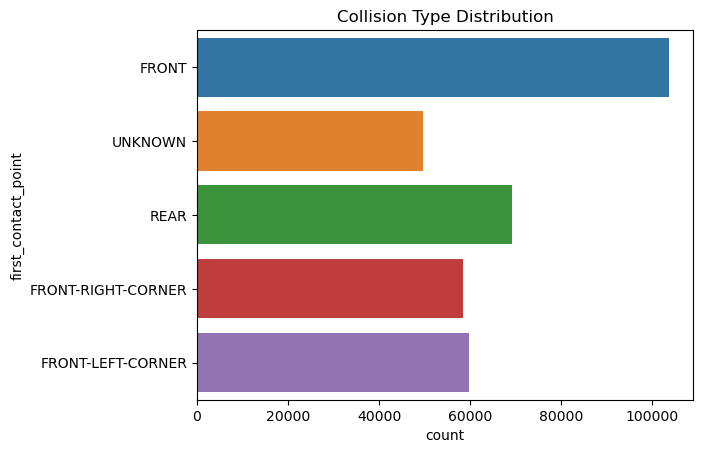

In [9]:
#we want to see where the fist point of intaraction was made during the crash
# Create the plot
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(y='first_contact_point', data=df)
plt.title("Collision Type Distribution")
plt.show()

From the graph above we see that the most of the vehicles have front collusions 

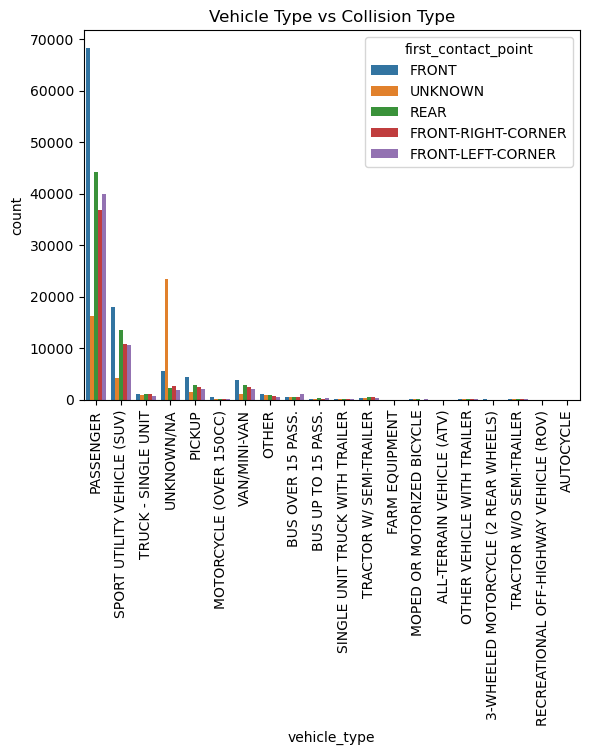

In [10]:
# we want to understand whether the tyoe of vehicle influences the type of collision occures
sns.countplot(x='vehicle_type', hue='first_contact_point', data=df)
plt.xticks(rotation=90)
plt.title("Vehicle Type vs Collision Type")
plt.show()

from the graph above we can clearly see that passanger cars are involved in  most of the crashes

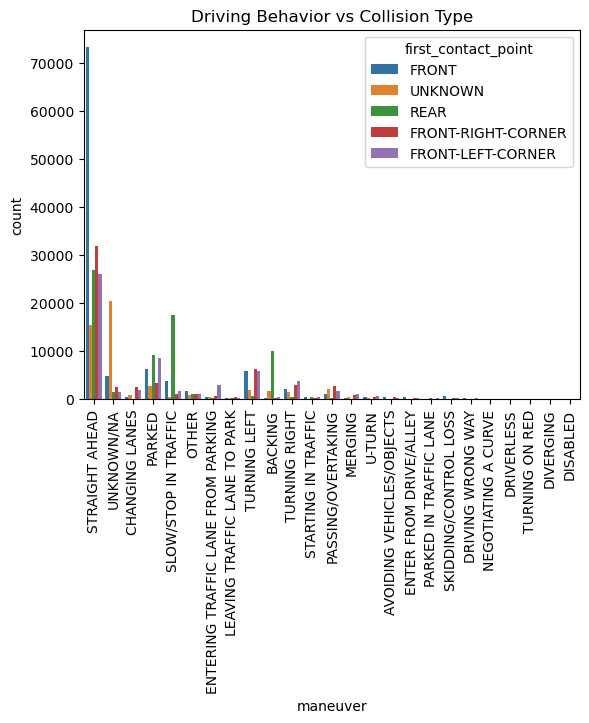

In [11]:
#understanding the drivers behaviour during the crash
sns.countplot(x='maneuver', hue='first_contact_point', data=df)
plt.xticks(rotation=90)
plt.title("Driving Behavior vs Collision Type")
plt.show()

from the graph we see that most of the drivers maneuvered straight ahead when causing the crash 

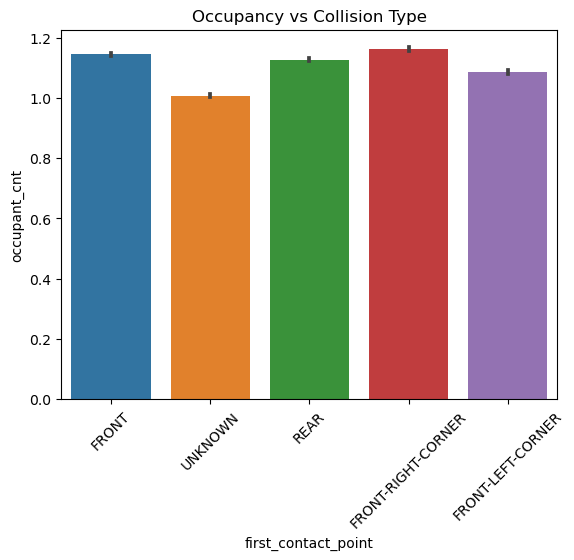

In [12]:
#determinig the occupancy of the vehicles in relation to the collusions

sns.barplot(x='first_contact_point', y='occupant_cnt', data=df)
plt.xticks(rotation=45)
plt.title("Occupancy vs Collision Type")
plt.show()

From the graph we see that Higher occupancy slightly linked to the front collision

# 5. Preprocessing 

In [13]:
from sklearn.preprocessing import LabelEncoder

label = LabelEncoder()
df['target'] = label.fit_transform(df['first_contact_point'])

In [28]:
#dropping the non predictive columns
# Drop IDs
df = df.drop(columns=['crash_record_id'], errors='ignore')

# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns

# Split into low/high cardinality
low_card = [col for col in cat_cols if df[col].nunique() < 20]
high_card = [col for col in cat_cols if df[col].nunique() >= 20]

# One-hot encode low-cardinality
df_encoded = pd.get_dummies(df, columns=low_card, drop_first=True)

In [15]:
#definining our features the y and x
#selecting numeric predictors
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

In [16]:
#selecting best features
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=15)
X_selected = selector.fit_transform(X, y)

C:\Users\Cynthia\anaconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


In [17]:
#separate training & test data
#dividing the dataset into training and data sets
#random state for reproductivity
#20% of the data will be used for testing ,80% for training
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=50)

# Modeling

In [21]:
#fitting the logistic regression model
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [22]:
#Predictions and Evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21028
           1       1.00      1.00      1.00     12003
           2       1.00      1.00      1.00     11444
           3       1.00      1.00      1.00     13745
           4       1.00      1.00      1.00      9928

    accuracy                           1.00     68148
   macro avg       1.00      1.00      1.00     68148
weighted avg       1.00      1.00      1.00     68148

[[21028     0     0     0     0]
 [    0 12003     0     0     0]
 [    0     0 11444     0     0]
 [    0     0     0 13745     0]
 [    0     0     0     0  9928]]
1.0


In [24]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=50)
dt_model.fit(X_train, y_train)
print(r2)

1.0


In [26]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(random_state=50)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     21028
           1       1.00      1.00      1.00     12003
           2       1.00      1.00      1.00     11444
           3       1.00      1.00      1.00     13745
           4       1.00      1.00      1.00      9928

    accuracy                           1.00     68148
   macro avg       1.00      1.00      1.00     68148
weighted avg       1.00      1.00      1.00     68148



The model demonstrated strong predictive capability across multiple collision types, with relatively balanced precision and recall scores. 

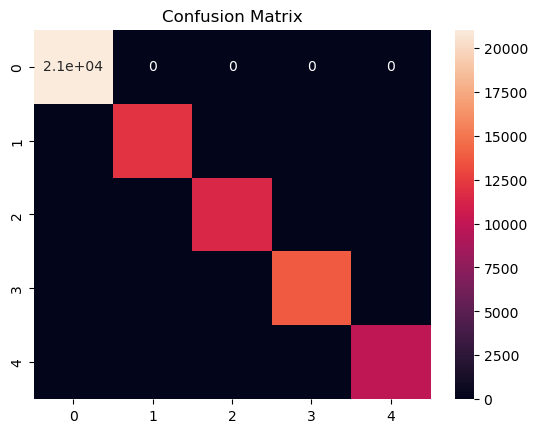

In [27]:
#visualzation of confusion matrix 

from sklearn.metrics import confusion_matrix
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True)
plt.title("Confusion Matrix")
plt.show()

The confusion matrix shows that the model performs well in identifying dominant collision patterns such as rear-end and frontal impacts, while some confusion exists among less frequent categories.

This evaluation confirms that the model is not overfitting and can generalize effectively to unseen data

## Recommendations

Based on the findings of this analysis, the following recommendations are proposed:

1. **Enhance Driver Behavior Interventions**
   - Focus on high-risk maneuvers such as turning and sudden stopping

2. **Vehicle-Specific Safety Policies**
   - Introduce stricter safety standards for high-risk vehicle categories
   - Encourage adoption of advanced safety features such as collision avoidance systems

3. **Occupancy-Based Safety Measures**
   - Promote seatbelt compliance and passenger safety awareness
   - Strengthen enforcement of occupancy-related regulations


## Conclusion 

The project successfully developed a multi-class classification model to predict crash collision patterns using vehicle characteristics, occupancy data, and driving behavior indicators. 

Despite the absence of direct accident cause labels, the analysis demonstrates that meaningful insights into crash dynamics can be derived from available vehicle-level data. The Random Forest model proved effective in capturing complex relationships within the data and provided reliable predictions across multiple collision categories.

The findings highlight the importance of integrating vehicle, human, and behavioral factors when analyzing traffic accidents, reinforcing the value of data-driven approaches in improving road safety outcomes.